#### Importing Necessary Libraries:

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

#### 2) Loading Data:

In [2]:
df = pd.read_csv('zoo.csv')

In [3]:
df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [4]:
df.shape

(101, 18)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
hair,101.0,0.425743,0.496921,0.0,0.0,0.0,1.0,1.0
feathers,101.0,0.198020,0.400495,0.0,0.0,0.0,0.0,1.0
eggs,101.0,0.584158,0.495325,0.0,0.0,1.0,1.0,1.0
milk,101.0,0.405941,0.493522,0.0,0.0,0.0,1.0,1.0
airborne,101.0,0.237624,0.427750,0.0,0.0,0.0,0.0,1.0
aquatic,101.0,0.356436,0.481335,0.0,0.0,0.0,1.0,1.0
predator,101.0,0.554455,0.499505,0.0,0.0,1.0,1.0,1.0
toothed,101.0,0.603960,0.491512,0.0,0.0,1.0,1.0,1.0
backbone,101.0,0.821782,0.384605,0.0,1.0,1.0,1.0,1.0
breathes,101.0,0.792079,0.407844,0.0,1.0,1.0,1.0,1.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal_name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  class_type   101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB


#### 3) Data Exploration and Transformation:

In [8]:
df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [9]:
print(df['animal_name'].nunique())
print(df['class_type'].value_counts())

100
class_type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64


- Animal name is Unique for all the records.
- Class Type is a Target/Label type variable for all the records.
- We can drop both of these before clustering.

In [10]:
df.drop(['animal_name', 'class_type'], axis=1, inplace= True)

In [11]:
df.head()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize
0,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
1,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1
2,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0
3,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1
4,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1


##### 1) Checking Features:

In [15]:
for col in df.columns:
    print('-' * 20)
    print(col)
    print(df[col].nunique())

--------------------
hair
2
--------------------
feathers
2
--------------------
eggs
2
--------------------
milk
2
--------------------
airborne
2
--------------------
aquatic
2
--------------------
predator
2
--------------------
toothed
2
--------------------
backbone
2
--------------------
breathes
2
--------------------
venomous
2
--------------------
fins
2
--------------------
legs
6
--------------------
tail
2
--------------------
domestic
2
--------------------
catsize
2


- Since data is mostly binary, Min-Max Scaling is usually the best approach here to force everything into a [0, 1] range.

#### 4) Scaling:

In [17]:
mn = MinMaxScaler()
X = mn.fit_transform(df)
X

array([[1., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 0., 1.],
       [0., 0., 1., ..., 1., 0., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 1., 0., 0.]], shape=(101, 16))

#### 5) Clustering:

In [19]:
agc1 = AgglomerativeClustering(n_clusters= 7, metric= 'euclidean', linkage= 'ward')
agc2 = AgglomerativeClustering(n_clusters= 7, metric= 'manhattan', linkage= 'complete')

clusters_w = agc1.fit_predict(X)
clusters_c = agc2.fit_predict(X)

In [20]:
clusters_w

array([0, 2, 6, 0, 0, 2, 2, 6, 6, 2, 0, 1, 6, 5, 5, 5, 1, 2, 6, 0, 1, 1,
       2, 1, 4, 3, 3, 2, 2, 0, 4, 2, 0, 1, 6, 2, 2, 1, 6, 4, 4, 1, 4, 1,
       0, 0, 5, 0, 0, 2, 0, 4, 3, 5, 2, 2, 1, 1, 1, 1, 6, 6, 3, 0, 0, 2,
       0, 0, 0, 0, 2, 1, 3, 6, 0, 0, 3, 5, 1, 1, 3, 4, 6, 1, 2, 5, 6, 1,
       4, 3, 1, 3, 6, 2, 2, 1, 2, 4, 0, 4, 1])

In [21]:
clusters_c

array([3, 3, 2, 3, 3, 3, 3, 2, 2, 3, 3, 1, 2, 0, 0, 0, 1, 3, 2, 5, 1, 1,
       3, 1, 4, 6, 6, 3, 3, 3, 4, 3, 3, 1, 2, 3, 3, 1, 2, 4, 4, 1, 4, 1,
       3, 3, 0, 3, 5, 3, 3, 4, 6, 0, 3, 3, 1, 1, 1, 1, 2, 2, 6, 5, 3, 3,
       5, 3, 3, 3, 3, 1, 0, 2, 5, 5, 2, 0, 1, 1, 6, 4, 2, 1, 3, 0, 2, 1,
       4, 6, 1, 6, 2, 3, 3, 1, 3, 4, 3, 4, 1])

#### 6) Dendrograms:

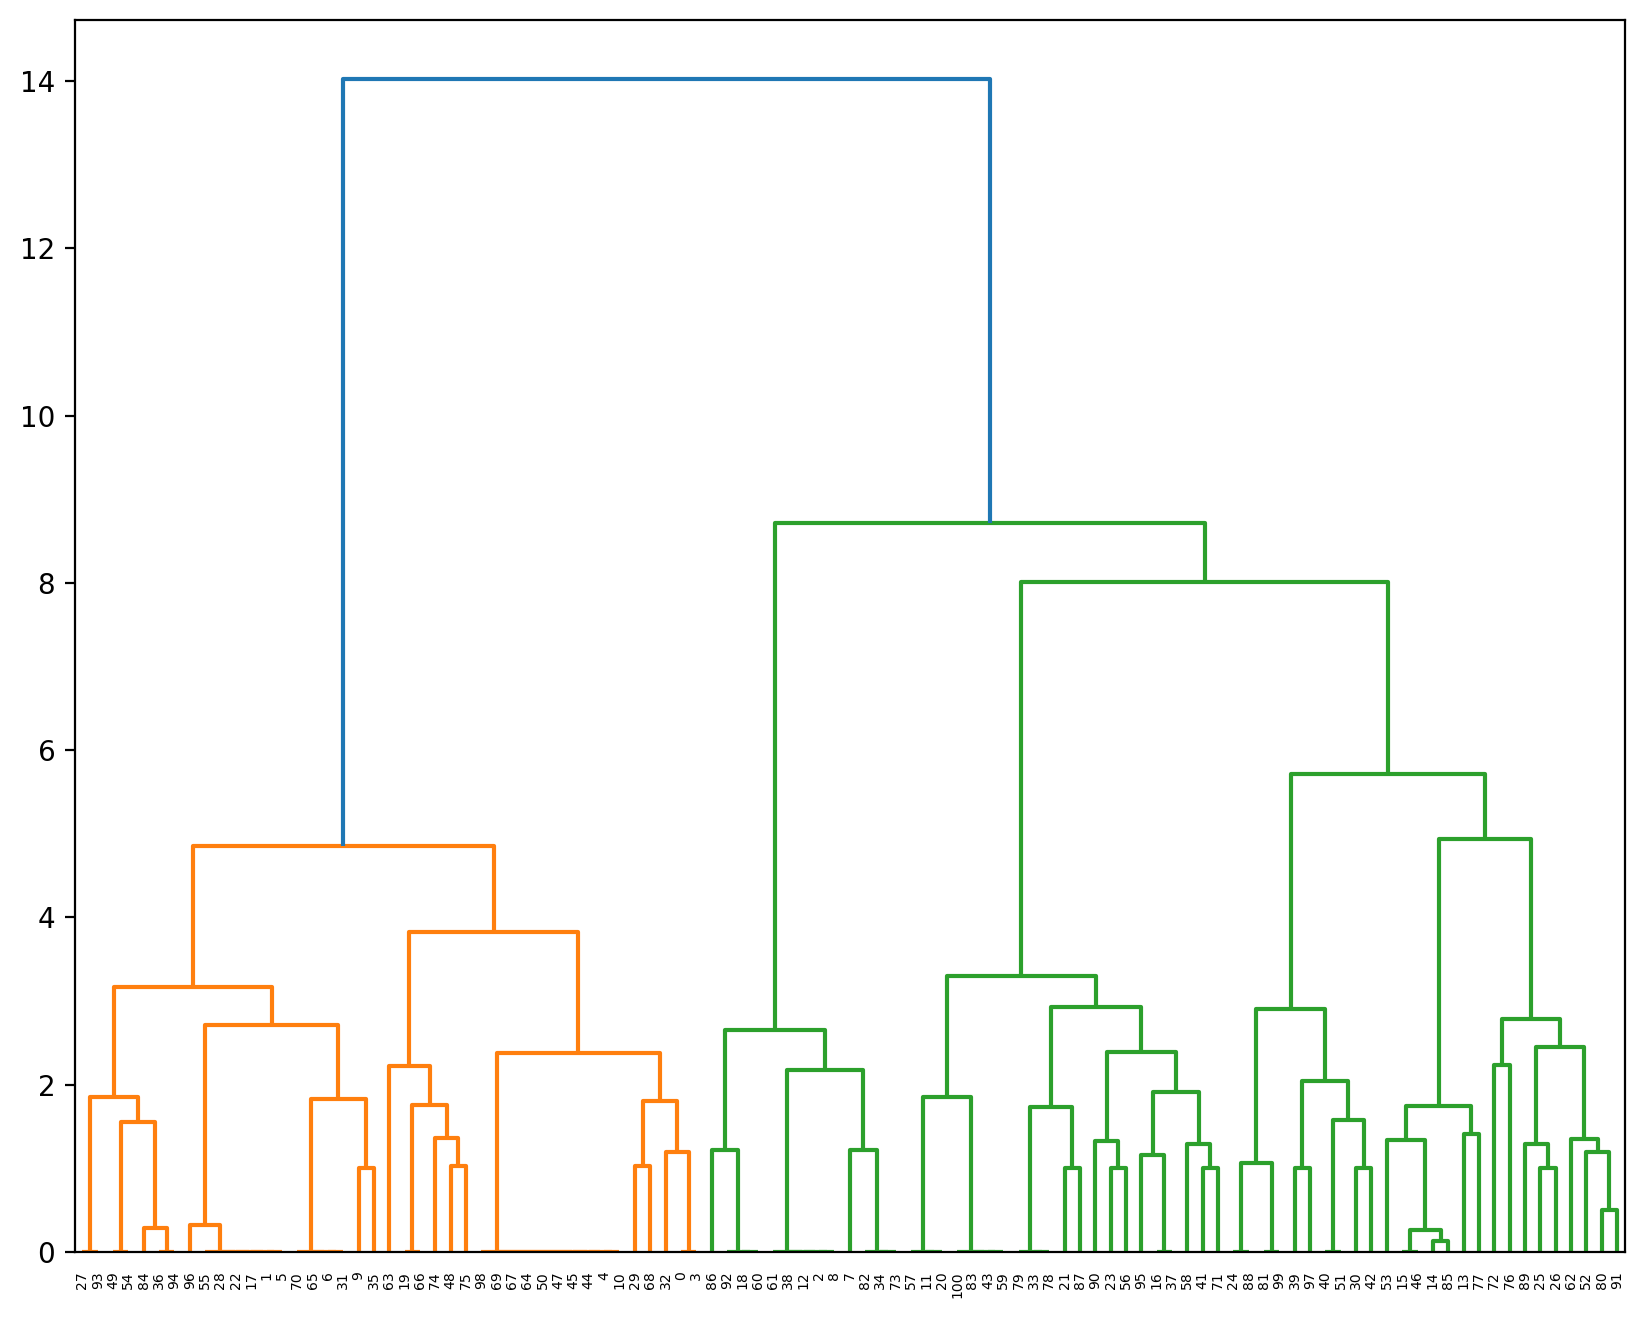

In [27]:
plt.figure(figsize= (10,8), dpi= 200)
dendrogram_w = sch.dendrogram(sch.linkage(X, method='ward'))
plt.show()

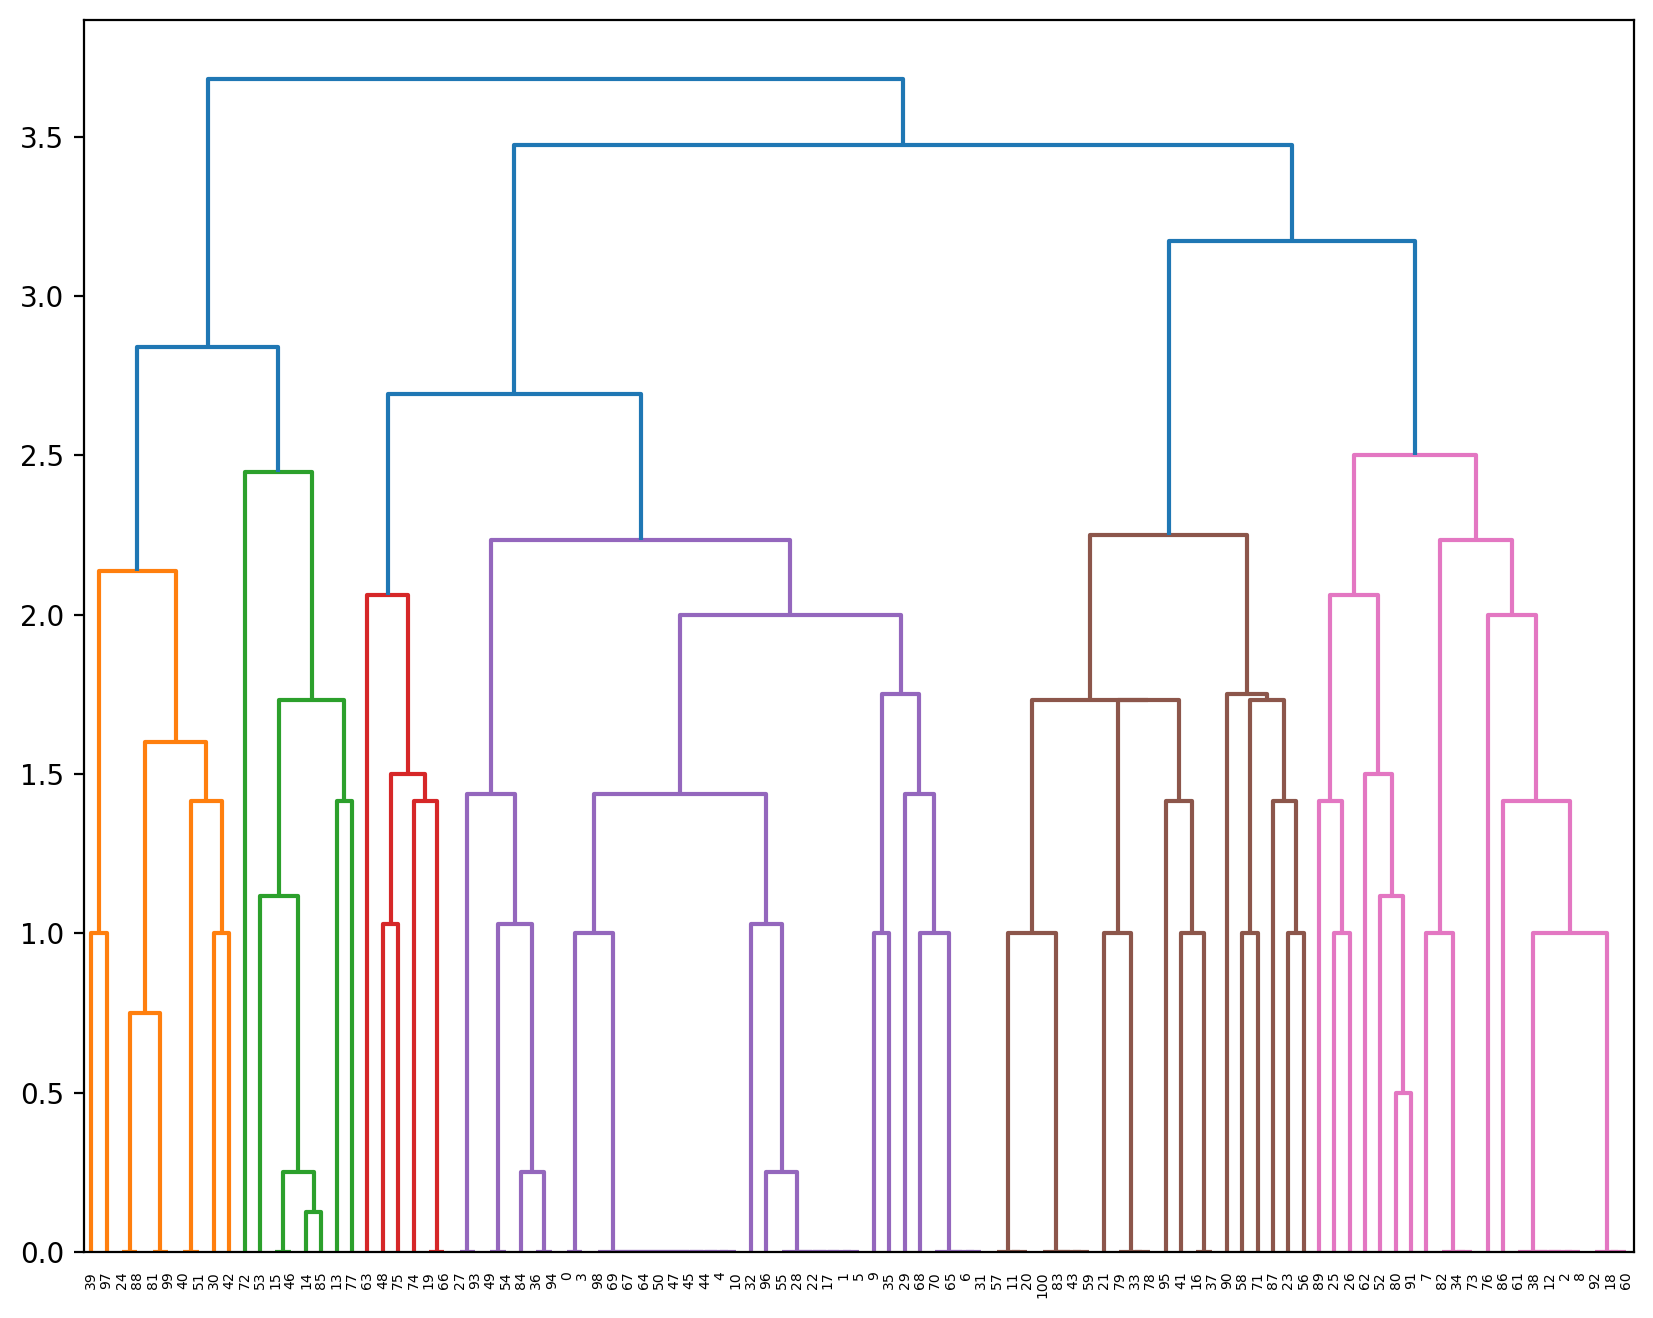

In [26]:
plt.figure(figsize= (10,8), dpi= 200)
dendrogram_c = sch.dendrogram(sch.linkage(X, method='complete'))
plt.show()